In [1]:
import pandas as pd

In [2]:
A=pd.read_csv("car_price_prediction_.csv")
A

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5


In [3]:
A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [4]:
import numpy as np

np. mean(A["Mileage"])

np.float64(149749.8448)

In [5]:
A["Engine Size"].unique()

array([2.3, 4.4, 4.5, 4.1, 2.6, 2.4, 4. , 5.3, 5.7, 1.5, 1.8, 4.7, 5.4,
       2. , 3.9, 3. , 1.1, 3.3, 5.8, 5.2, 1.9, 5.9, 1. , 3.2, 5.6, 4.6,
       4.2, 2.2, 2.1, 1.3, 1.4, 5. , 5.1, 3.7, 3.6, 2.9, 2.8, 5.5, 4.3,
       4.9, 3.1, 2.5, 3.5, 4.8, 1.6, 3.8, 2.7, 1.7, 3.4, 6. , 1.2])

In [6]:
A.columns[A.isnull().any()]

Index([], dtype='object')

In [7]:
kd=A.select_dtypes(["int64","float64"])
kd

,Car ID,Year,Engine Size,Mileage,Price
0,1,2016,2.3,114832,26613.92
1,2,2018,4.4,143190,14679.61
2,3,2013,4.5,181601,44402.61
3,4,2011,4.1,68682,86374.33
4,5,2009,2.6,223009,73577.10
...,...,...,...,...,...
2495,2496,2020,2.4,22650,61384.10
2496,2497,2001,5.7,77701,24710.35
2497,2498,2021,1.1,272827,29902.45
2498,2499,2002,4.5,229164,46085.67


In [8]:
kd.kurt()

Car ID        -1.200000
Year          -1.243076
Engine Size   -1.182948
Mileage       -1.224952
Price         -1.207752
dtype: float64

In [9]:
kd.corr()

,Car ID,Year,Engine Size,Mileage,Price
Car ID,1.000000,0.008050,0.000059,-0.035840,0.004650
Year,0.008050,1.000000,0.011833,0.002282,-0.036805
Engine Size,0.000059,0.011833,1.000000,-0.015782,-0.004420
Mileage,-0.035840,0.002282,-0.015782,1.000000,-0.008567
Price,0.004650,-0.036805,-0.004420,-0.008567,1.000000


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x=kd[["Mileage","Engine Size"]]
y=kd["Price"]

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train

,Mileage,Engine Size
2055,73401,3.4
1961,252234,1.6
1864,89882,5.8
2326,275333,4.6
461,41190,3.2
...,...,...
1638,69072,4.9
1095,127521,2.9
1130,80636,3.2
1294,6336,4.8


In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
from sklearn.metrics import r2_score

In [15]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = lr.predict(x_test)
y_pred

array([52419.31895556, 52561.01278255, 52510.93076662, 52445.32261561,
       52323.26656328, 52163.28357399, 52475.63417732, 52873.88067351,
       52150.16401918, 52449.22448397, 52515.3519493 , 52557.28628188,
       52619.6237516 , 52519.64466815, 52153.31787501, 52141.3863135 ,
       52297.50328361, 52568.64953924, 52910.17410907, 52277.54782171,
       52417.89606543, 52375.57943879, 52508.59257471, 52774.82390861,
       52009.41972874, 52806.0779025 , 52487.28367272, 52417.95657508,
       52568.35400779, 52222.25021565, 52353.74827456, 52275.27451753,
       52529.87280665, 52417.64778443, 52320.15709116, 52603.22924051,
       52680.96200178, 52838.24801631, 51969.30928572, 52924.64397181,
       52724.10865701, 53001.35234413, 51984.02888152, 52588.55998352,
       52632.71201955, 52618.85328954, 52263.19703274, 52543.89290818,
       52360.02459628, 52314.46321663, 52982.39141448, 52473.1717528 ,
       52159.31863846, 52862.19692144, 52373.67566293, 52388.11263989,
      

In [17]:
lr.coef_

array([-1.73937525e-03, -1.38678547e+02])

In [18]:
lr.intercept_

np.float64(53203.86559400479)

In [19]:
r2_score(y_test,y_pred)

-0.0009685920079551824

In [20]:
i=[[4.0,80]]
lr.predict((i))

C:\Users\karth\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([42109.57491259])

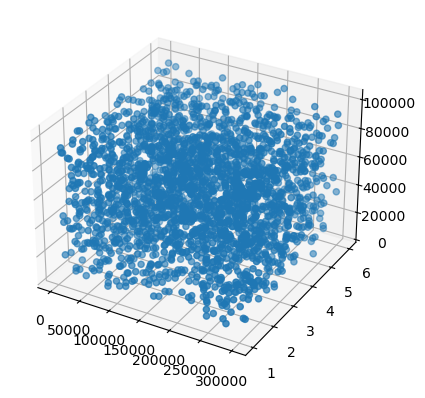

In [21]:
import matplotlib.pyplot as plt 
fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x["Mileage"],x["Engine Size"],y)
plt.show()